# 01 - Data Overview & EDA + Evaluation




## 1. Import Libraries.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# For evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

pd.set_option('mode.chained_assignment', None)


## 2. Load Raw Dataset


In [45]:
# Load classification dataset
df_classification = pd.read_csv('data/raw/diabetes.csv')

# Load clustering dataset
df_clustering = pd.read_csv('data/raw/retail_store_sales.csv')


## 3. Dataset Overview - Classification


In [46]:
print("Classification Dataset Shape:", df_classification.shape)
display(df_classification.head())
display(df_classification.info())


Classification Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

## 4. Missing Values Overview


In [47]:
missing_overview = df_classification.isnull().sum()
missing_percent = (missing_overview / len(df_classification)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_overview,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
display(missing_df)


,Missing Count,Percentage


## 5. Duplicates Overview


In [48]:
duplicate_count = df_classification.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df_classification)) * 100:.2f}%")


Number of duplicate rows: 0
Percentage of duplicates: 0.00%


## 6. Basic Visualizations


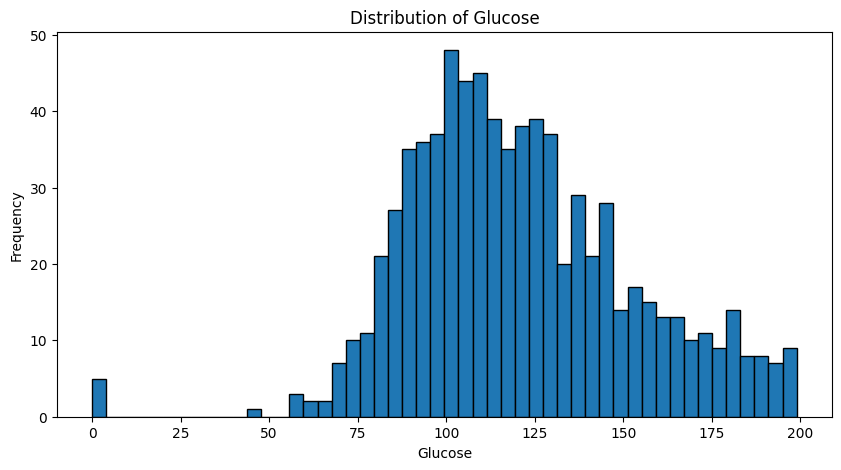

In [49]:
# Visualization 1: Distribution of Glucose
plt.figure(figsize=(10, 5))
plt.hist(df_classification['Glucose'], bins=50, edgecolor='black')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Distribution of Glucose')
plt.show()


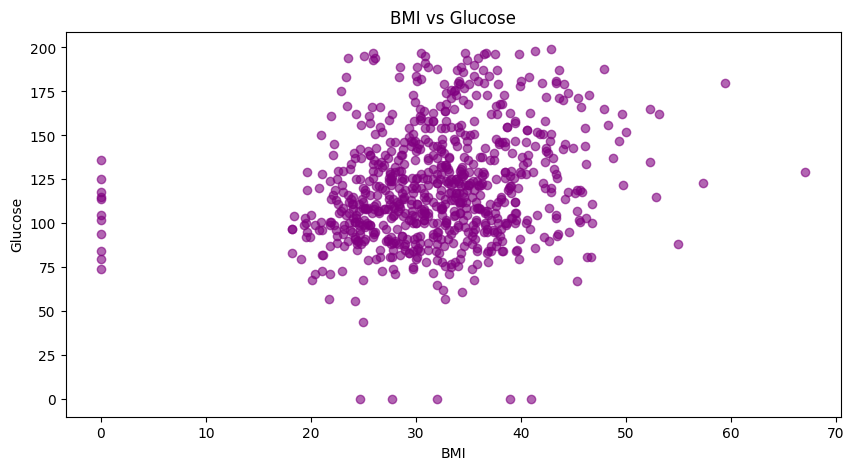

In [50]:
# Visualization 2: Scatter plot - BMI vs Glucose
plt.figure(figsize=(10, 5))
plt.scatter(df_classification['BMI'], df_classification['Glucose'], alpha=0.6, color='purple')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.title('BMI vs Glucose')
plt.show()


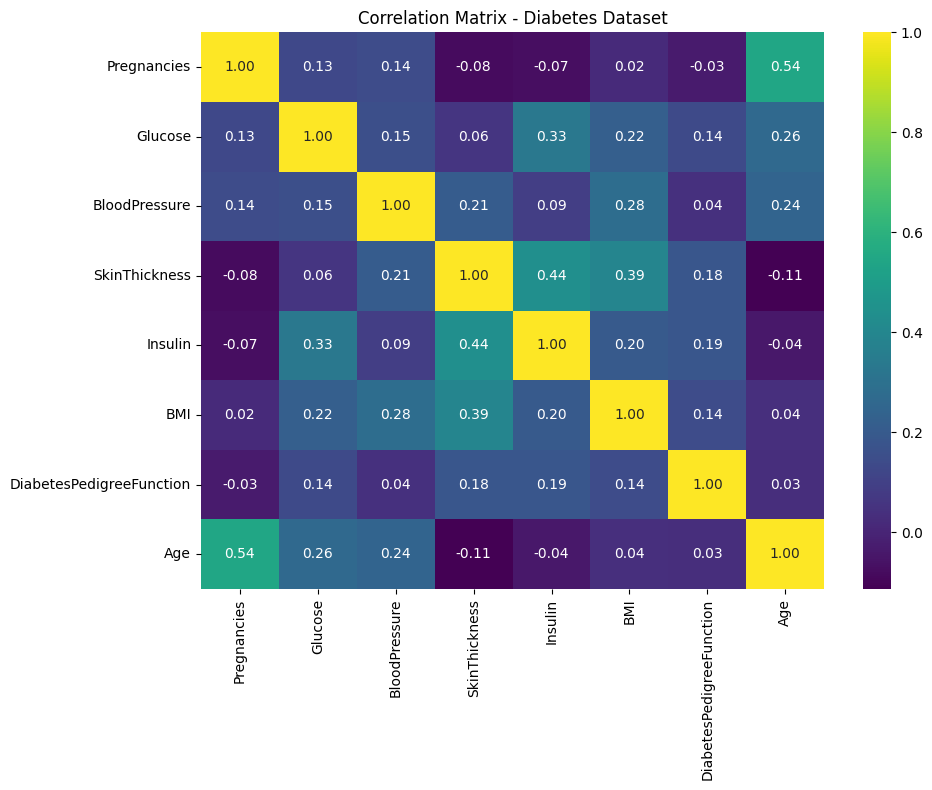

In [51]:
# Visualization 3: Correlation Matrix
numeric_cols = df_classification.select_dtypes(include=[np.number])
# Exclude Outcome column for correlation (it's the target)
numeric_cols = numeric_cols.drop(columns=['Outcome'], errors='ignore')

if not numeric_cols.empty and numeric_cols.shape[1] > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap='viridis')
    plt.title('Correlation Matrix - Diabetes Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No sufficient numeric columns for correlation matrix.")


## 7. Evaluation - Supervised Models

**Note**: This section evaluates the supervised models after they are trained .
Load the predictions from the trained models and evaluate them.


In [52]:
# Load preprocessed data 
X_test = pd.read_csv('data/processed/X_test_diabetes.csv')
y_test = pd.read_csv('data/processed/y_test_diabetes.csv')



# Load model predictions and evaluate

try:
    y_pred_lr = pd.read_csv('data/processed/y_pred_lr.csv').values.flatten()
    y_pred_nb = pd.read_csv('data/processed/y_pred_nb.csv').values.flatten()
    y_pred_dt = pd.read_csv('data/processed/y_pred_dt.csv').values.flatten()
    y_pred_svm = pd.read_csv('data/processed/y_pred_svm.csv').values.flatten()

    # Load predicted probabilities for ROC-AUC
    y_proba_lr = pd.read_csv('data/processed/y_proba_lr.csv').values
    y_proba_nb = pd.read_csv('data/processed/y_proba_nb.csv').values
    y_proba_dt = pd.read_csv('data/processed/y_proba_dt.csv').values
    y_proba_svm = pd.read_csv('data/processed/y_proba_svm.csv').values
    
    y_test = y_test.values.flatten()
    
    models = {
        'Logistic Regression': (y_pred_lr, y_proba_lr),
        'Naive Bayes': (y_pred_nb, y_proba_nb),
        'Decision Tree': (y_pred_dt, y_proba_dt),
        'SVM': (y_pred_svm, y_proba_svm)
    }
    
    # Calculate metrics for each model
    results = []
    for model_name, (y_pred, y_proba) in models.items():
        accuracy_pct = accuracy_score(y_test, y_pred) * 100
        precision_pct = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        recall_pct = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        f1_pct = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

        # ROC-AUC for binary classification (use positive class probabilities)
        # y_proba is shape (n_samples, 2) for binary classification
        # We need the probabilities for the positive class (column index 1)
        if y_proba.ndim > 1 and y_proba.shape[1] > 1:
            # Binary classification: use positive class probabilities
            y_proba_positive = y_proba[:, 1]
        else:
            # Already 1D or single column
            y_proba_positive = y_proba.flatten() if y_proba.ndim > 1 else y_proba
        
        roc_auc_pct = roc_auc_score(y_test, y_proba_positive) * 100

        results.append({
            'Model': model_name,
            'Accuracy (%)': round(accuracy_pct, 2),
            'Precision (%)': round(precision_pct, 2),
            'Recall (%)': round(recall_pct, 2),
            'F1-Score (%)': round(f1_pct, 2),
            'ROC-AUC (%)': round(roc_auc_pct, 2)
        })
    
    results_df = pd.DataFrame(results)
    display(results_df)
    
except FileNotFoundError:
    print("Model predictions not found. Please run Person 6's notebook first to generate predictions.")
    print("Expected files:")
    print("- data/processed/y_pred_lr.csv")
    print("- data/processed/y_pred_nb.csv")
    print("- data/processed/y_pred_dt.csv")
    print("- data/processed/y_pred_svm.csv")
    print("- data/processed/y_proba_lr.csv")
    print("- data/processed/y_proba_nb.csv")
    print("- data/processed/y_proba_dt.csv")
    print("- data/processed/y_proba_svm.csv")


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,Logistic Regression,72.08,73.40,72.08,72.49,80.52
1,Naive Bayes,70.13,73.33,70.13,70.79,79.63
2,Decision Tree,73.38,74.33,73.38,73.70,78.53
3,SVM,71.43,71.20,71.43,71.30,79.04


## 8. Confusion Matrix Visualization


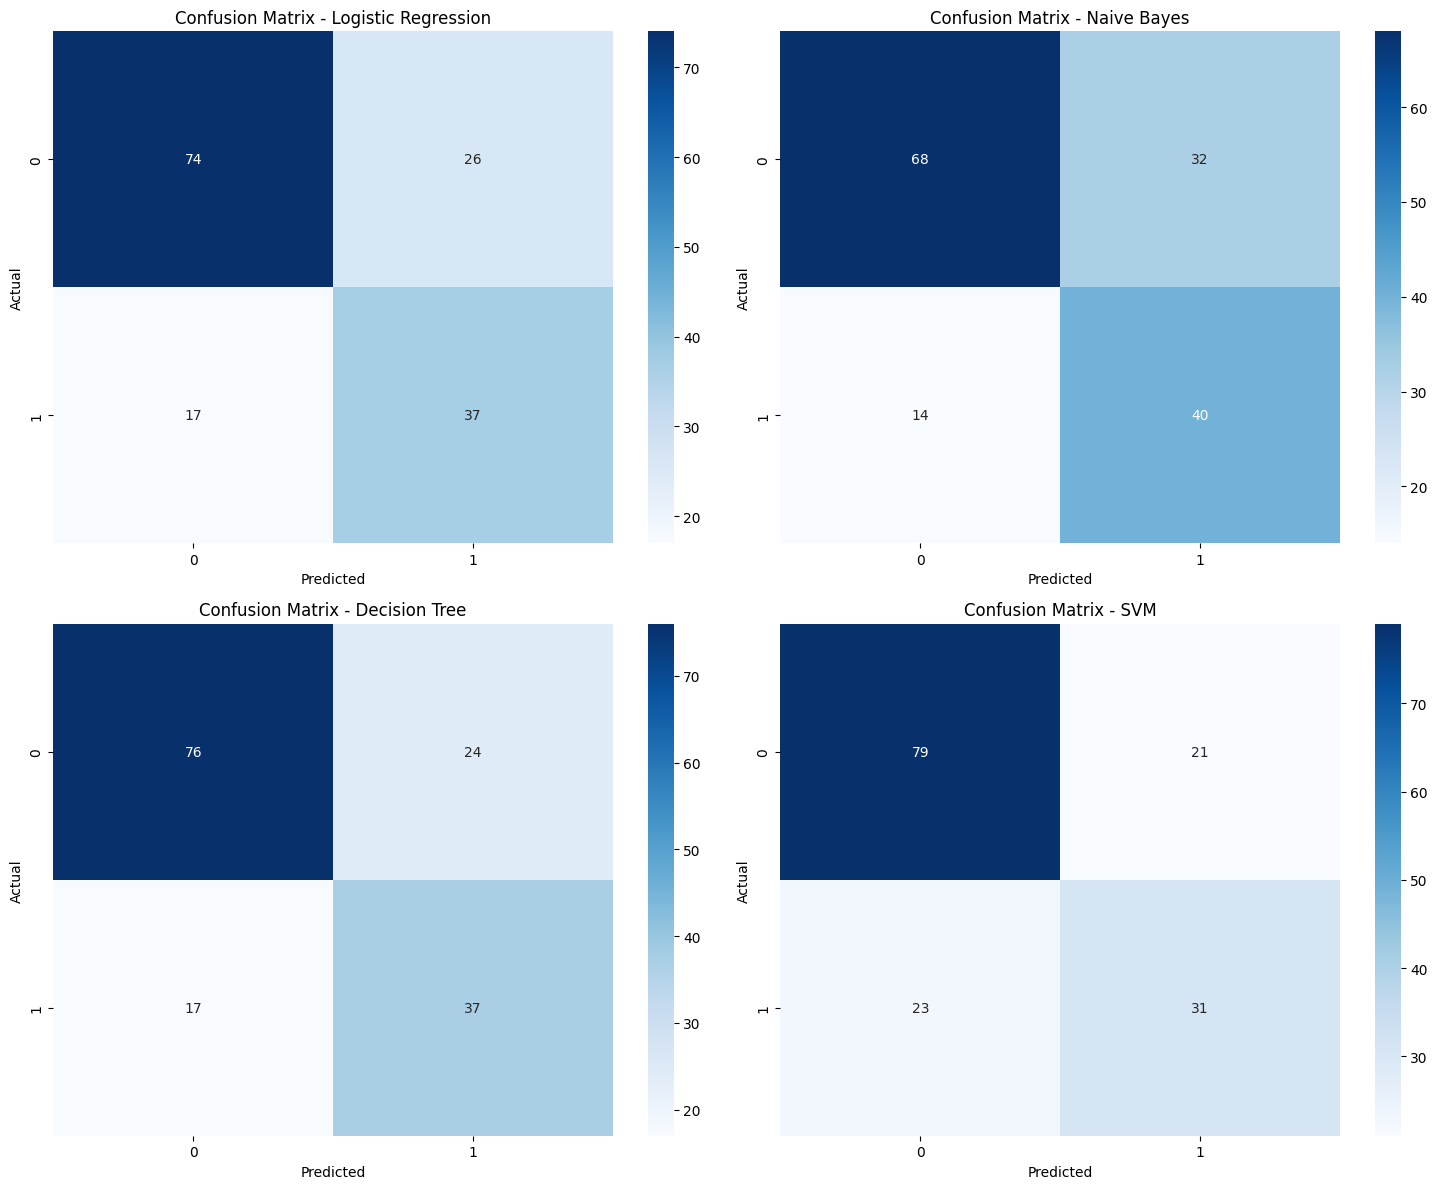

In [53]:
try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, (model_name, (y_pred, _)) in enumerate(models.items()):
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'Confusion Matrix - {model_name}')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("Models dictionary not found. Please run the evaluation cell above first.")


## 9. Classification Report


In [54]:
try:
    for model_name, (y_pred, _) in models.items():
        print(f"\n{'='*50}")
        print(f"Classification Report - {model_name}")
        print(f"{'='*50}")
        print(classification_report(y_test, y_pred))
        
except NameError:
    print("Models dictionary not found. Please run the evaluation cell above first.")



Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       100
           1       0.59      0.69      0.63        54

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154


Classification Report - Naive Bayes
              precision    recall  f1-score   support

           0       0.83      0.68      0.75       100
           1       0.56      0.74      0.63        54

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       100
           1       0.61      0.69      0.64        54

    accuracy                           0.73       154
   macr